In [62]:
import BiSSGL as BiSSGL
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
import matplotlib.pyplot as plt
import seaborn as sns  # optional, for nicer heatmaps


def plot_matrices(U, V):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.heatmap(U, ax=axes[0], cmap="viridis", cbar=True)
    axes[0].set_title("Latent Matrix A")

    sns.heatmap(V, ax=axes[1], cmap="viridis", cbar=True)
    axes[1].set_title("Latent Matrix B")

    plt.tight_layout()
    plt.show()

In [41]:
# This is new simulation setting for the feature selection:
I = 800
J = 1600
d = d1 = d2 = 100
K = K1 = K2 = 25

U = np.random.normal(0, np.sqrt(0.05), size=(I, d1))
U_true = U[:, :K1]
V = np.random.normal(0, np.sqrt(0.05), size=(J, d2))
V_true = V[:, :K2]
A_true = np.eye(K1)
B_true = np.eye(K2)

Pr = expit(U_true @ A_true @ B_true.T @ V_true.T)
Y_true = (Pr > 0.55).astype(int)

sparsity = 0.01
index = np.array(np.meshgrid(np.arange(I), np.arange(J))).T.reshape(-1, 2)
masked_indices = index[
    np.random.choice(index.shape[0], size=int((1 - sparsity) * I * J), replace=False)
]
Y_masked = Y_true[masked_indices[:, 0], masked_indices[:, 1]]
Y = Y_true.copy()
Y[masked_indices[:, 0], masked_indices[:, 1]] = 0

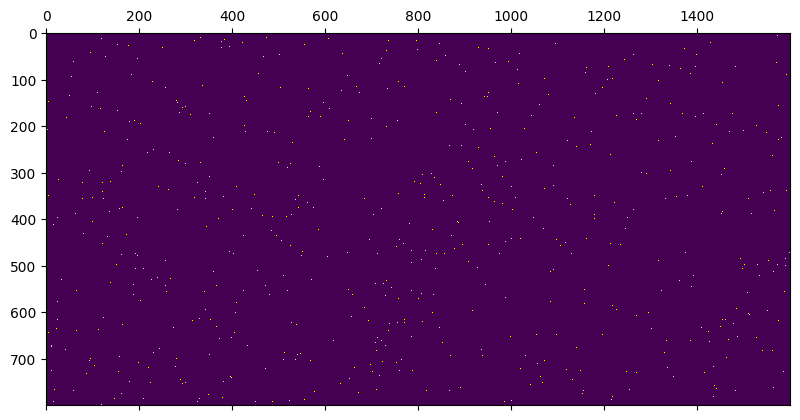

In [101]:
plt.matshow(Y)

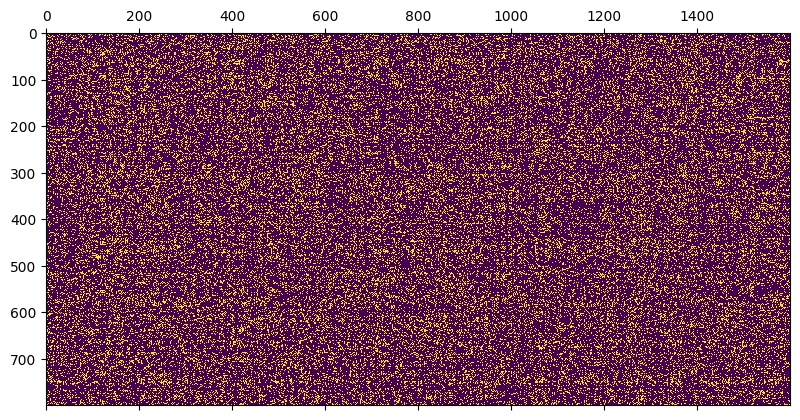

In [102]:
plt.matshow(Y_true)

In [25]:
# This is new simulation setting for the feature selection:
I = 800
J = 1600
d = d1 = d2 = 100
K = K1 = K2 = 25

U = np.random.normal(0, np.sqrt(0.01), size=(I, d1))
U_true = U[:, :K1]
V = np.random.normal(0, np.sqrt(0.01), size=(J, d2))
V_true = V[:, :K2]
A_true = np.ones((K, K))
B_true = np.ones((K, K))

Pr = expit(U_true @ A_true @ B_true.T @ V_true.T)
Y_true = (Pr > 0.5).astype(int)

sparsity = 0.01
index = np.array(np.meshgrid(np.arange(I), np.arange(J))).T.reshape(-1, 2)
masked_indices = index[
    np.random.choice(index.shape[0], size=int((1 - sparsity) * I * J), replace=False)
]
Y_masked = Y_true[masked_indices[:, 0], masked_indices[:, 1]]
Y = Y_true.copy()
Y[masked_indices[:, 0], masked_indices[:, 1]] = 0

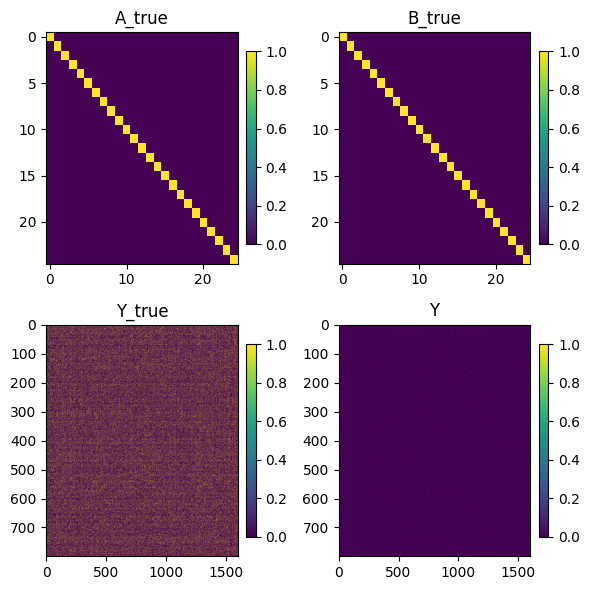

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))

axes[0, 0].imshow(A_true, aspect="auto", cmap="viridis")
axes[0, 0].set_title("A_true")
plt.colorbar(axes[0, 0].images[0], ax=axes[0, 0], fraction=0.046, pad=0.04)

axes[0, 1].imshow(B_true, aspect="auto", cmap="viridis")
axes[0, 1].set_title("B_true")
plt.colorbar(axes[0, 1].images[0], ax=axes[0, 1], fraction=0.046, pad=0.04)

axes[1, 0].imshow(Y_true, aspect="auto", cmap="viridis")
axes[1, 0].set_title("Y_true")
plt.colorbar(axes[1, 0].images[0], ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].imshow(Y, aspect="auto", cmap="viridis")
axes[1, 1].set_title("Y")
plt.colorbar(axes[1, 1].images[0], ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [103]:
np.sum(Y)

np.int64(2684)

In [9]:
# U.shape, V.shape, A_true.shape
A = np.zeros((d1, K))
A[range(K)] = A_true
A[K:] = np.random.normal(size=A[K:].shape) / 10
Ainput = A.copy()

B = np.zeros((d2, K))
B[range(K)] = B_true
B[K:] = np.random.normal(size=B[K:].shape) / 10
Binput = B.copy()

In [ ]:
plt.matshow(Ainput)
# print(Ainput)

In [ ]:
est_mu, est_A, est_B, logLik = BiSSGL.optimization(
    Y_true,
    U=U,
    V=V,
    xi=1,
    eta=0.0001,
    tilde_lambda0=5,
    tilde_lambda1=1,
    tilde_alpha=1 / K,
    tilde_beta=1,
    lambda0=5,
    lambda1=1,
    alpha=1 / K,
    beta=1,
    K=K,
    max_iter=1000,
    tol=1e-5,
    # A=Ainput,
    # B=Binput,
)

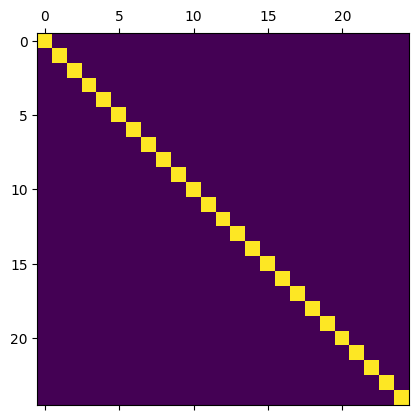

In [112]:
plt.matshow(A_true)

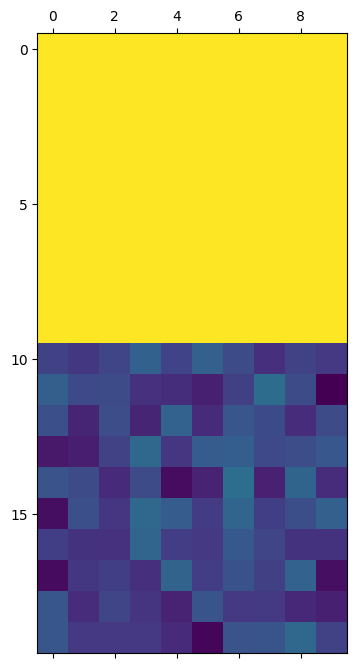

In [116]:
plt.matshow(Ainput)

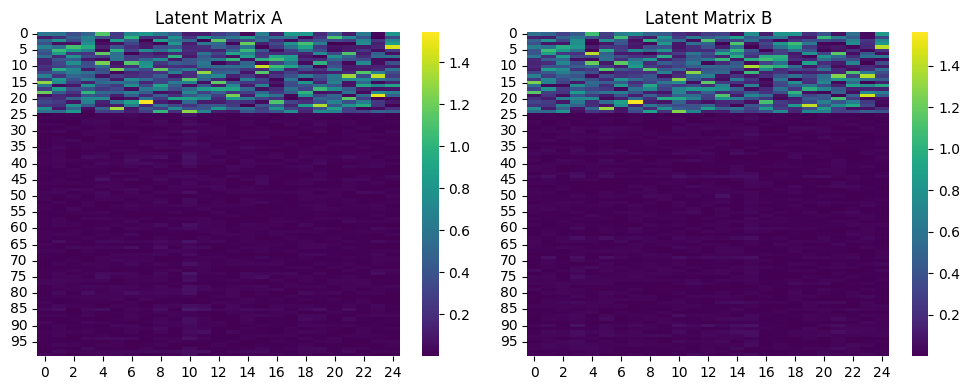

In [113]:
plot_matrices(np.abs(est_A), np.abs(est_B))

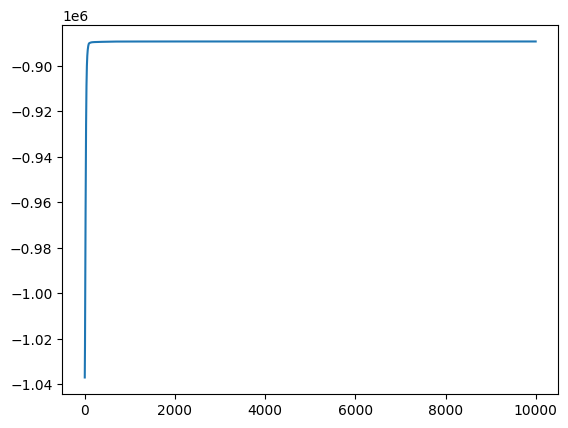

In [77]:
plt.plot(range(len(logLik)), logLik)

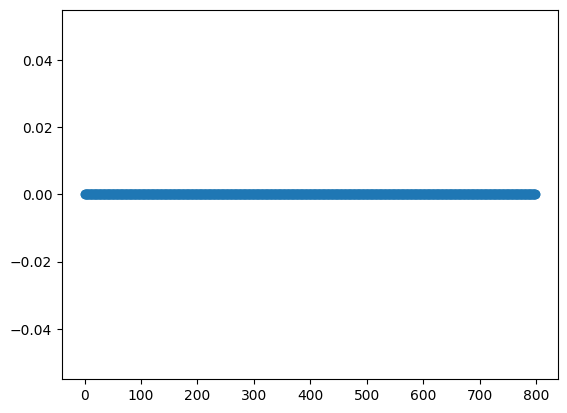

In [65]:
plt.plot(est_mu, marker="o")

In [ ]:
print(est_A)

<StemContainer object of 3 artists>

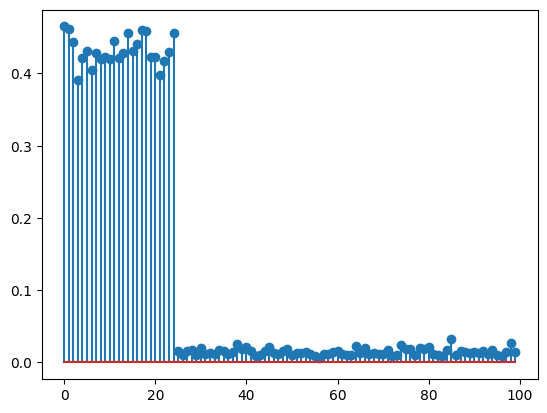

In [108]:
plt.stem(np.abs(est_A).mean(axis=1))

In [109]:
est_pr = expit(U @ est_A @ est_B.T @ V.T)
est_pr_masked = est_pr[masked_indices[:, 0], masked_indices[:, 1]]
y_test = Y_masked
y_score = est_pr_masked

In [110]:
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.metrics import auc


# Data to plot precision - recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_score)
# Use AUC function to calculate the area under the curve of precision recall curve
auc_precision_recall = auc(recall, precision)
print(auc_precision_recall)

0.9933487876847166


In [114]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc_tpr_fpr = auc(tpr, 1 - fpr)
print(auc_tpr_fpr)

print(roc_auc_score(y_test, y_score))

0.9981668887405026
0.9981668887405026
